<a href="https://colab.research.google.com/github/shahabday/Deeplearning_challenge_erum_seasnot/blob/main/01_pytorch_dataloader_with_normalization_training_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gdown

import gdown

url = "https://drive.google.com/file/d/1rD1GVJntPtyukfKNLt764sN13sSSwvel/view?usp=drive_link"

gdown.download(url, quiet=False, fuzzy=True)

FileURLRetrievalError: Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1rD1GVJntPtyukfKNLt764sN13sSSwvel

but Gdown can't. Please check connections and permissions.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:

!cp /content/drive/MyDrive/indico_challenge/data/savetheoceans.nc /


In [7]:
!ls /

bin			    kaggle		      opt		 srv
boot			    lib			      proc		 sys
content			    lib32		      python-apt	 tmp
cuda-keyring_1.1-1_all.deb  lib64		      python-apt.tar.xz  tools
datalab			    libx32		      root		 usr
dev			    media		      run		 var
etc			    mnt			      savetheoceans.nc
home			    NGC-DL-CONTAINER-LICENSE  sbin


In [2]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as npa

In [3]:
data = xr.open_dataset("/savetheoceans.nc")

In [ ]:
data

<xarray.Dataset> Size: 8GB
Dimensions:  (sample: 2803, channel: 12, x: 240, y: 240)
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 288B '442nm' '492nm' '559nm' ... '2186nm' 'labels'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
Data variables:
    data     (sample, channel, x, y) float32 8GB ...

In [ ]:
sample = data["data"].sel(sample = 3 )

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
data.isel(sample=0, channel=0)

<xarray.Dataset> Size: 231kB
Dimensions:  (x: 240, y: 240)
Coordinates:
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
    sample   int16 2B 0
    channel  <U6 24B '442nm'
Data variables:
    data     (x, y) float32 230kB ...

In [5]:
da = data["data"]

In [6]:
img = da.isel(sample=0, channel=0)

print("data dtype:", da.dtype)
print("img dtype:", img.dtype)
print("img shape:", img.shape)
print("values dtype:", img.values.dtype)
print("element type:", type(img.values[0,0]))
print("element value:", img.values[0,0])

data dtype: float32
img dtype: float32
img shape: (240, 240)
values dtype: float32
element type: <class 'numpy.float32'>
element value: 0.06999265


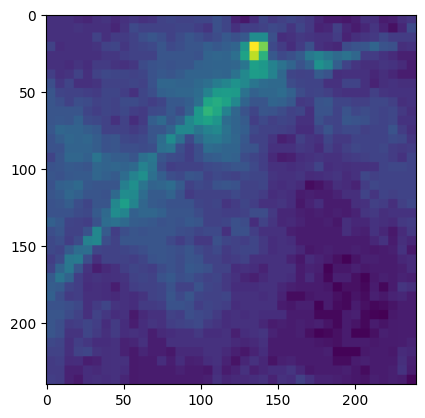

In [ ]:
plt.imshow(img)

#Classification of just Oil

## Data loader


In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset


class XarrayBinaryClassificationDataset(Dataset):
    """
    Converts segmentation labels into image-level binary classification.

    Target = 1 if target_class is present anywhere in the mask
           = 0 otherwise
    """

    def __init__(
        self,
        da,
        target_class,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
    ):
        self.da = da
        self.target_class = target_class
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        # sanity check: expected 11 input channels
        if len(self.input_channels) != 11:
            print(f"Warning: expected 11 input channels, found {len(self.input_channels)}")

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)

        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        return x.astype(np.float32)

    def _mask_to_binary_label(self, y_mask: np.ndarray) -> np.float32:
        # positive if target class exists anywhere
        label = (y_mask == self.target_class).any()
        return np.float32(label)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        y_mask = sample.sel(channel=self.label_channel).values

        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self._mask_to_binary_label(y_mask)

        x = torch.from_numpy(x)                      # shape: [11, H, W]
        y = torch.tensor(y, dtype=torch.float32)    # scalar float for BCEWithLogitsLoss

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

# Train split

In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset


def extract_binary_labels_from_da(da, target_class, label_channel="labels"):
    labels = []
    for i in range(da.sizes["sample"]):
        mask = da.isel(sample=i).sel(channel=label_channel).values
        labels.append(int((mask == target_class).any()))
    return np.array(labels)


def make_dataloaders(
    da,
    target_class,
    label_channel="labels",
    batch_size=16,
    num_workers=4,
    val_size=0.2,
    random_state=42,
):
    dataset = XarrayBinaryClassificationDataset(
        da=da,
        target_class=target_class,
        label_channel=label_channel,
        normalize=True,
        return_sample_id=False,
    )

    labels = extract_binary_labels_from_da(da, target_class, label_channel)
    indices = np.arange(len(dataset))

    train_idx, val_idx = train_test_split(
        indices,
        test_size=val_size,
        random_state=random_state,
        stratify=labels,
    )

    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, labels[train_idx], labels[val_idx]

# Model   Resnet

In [6]:
import torch
import torch.nn as nn
from torchvision import models


class ResNetBinaryClassifier(nn.Module):
    def __init__(self, in_channels=11, backbone="resnet50", pretrained=False):
        super().__init__()

        if backbone == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            self.model = models.resnet18(weights=weights)
            in_features = self.model.fc.in_features
        elif backbone == "resnet34":
            weights = models.ResNet34_Weights.DEFAULT if pretrained else None
            self.model = models.resnet34(weights=weights)
            in_features = self.model.fc.in_features
        elif backbone == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            self.model = models.resnet50(weights=weights)
            in_features = self.model.fc.in_features
        else:
            raise ValueError(f"Unsupported backbone: {backbone}")

        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        # better initialization for non-RGB input
        nn.init.kaiming_normal_(self.model.conv1.weight, mode="fan_out", nonlinearity="relu")

        # output one logit for binary classification
        self.model.fc = nn.Linear(in_features, 1)

    def forward(self, x):
        # returns logits, shape [B]
        return self.model(x).squeeze(1)

# Metrics

In [7]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)


def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    # ROC-AUC fails if only one class is present in y_true
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["roc_auc"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    return metrics

In [8]:
import torch


def get_pos_weight(train_labels):
    train_labels = np.asarray(train_labels)
    num_pos = (train_labels == 1).sum()
    num_neg = (train_labels == 0).sum()

    if num_pos == 0:
        raise ValueError("No positive samples in training set.")

    pos_weight = num_neg / max(num_pos, 1)
    return torch.tensor([pos_weight], dtype=torch.float32)

# Training

In [9]:
from tqdm import tqdm


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    all_probs = []
    all_targets = []

    for x, y in tqdm(loader, desc="Train", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        targets = y.detach().cpu().numpy()

        all_probs.extend(probs.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_targets, all_probs, threshold=0.5)
    metrics["loss"] = epoch_loss
    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    all_probs = []
    all_targets = []

    for x, y in tqdm(loader, desc="Val", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        running_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits).cpu().numpy()
        targets = y.cpu().numpy()

        all_probs.extend(probs.tolist())
        all_targets.extend(targets.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_binary_metrics(all_targets, all_probs, threshold=0.5)
    metrics["loss"] = epoch_loss
    return metrics

In [10]:
import copy
import torch
import torch.optim as optim


def train_model(
    da,
    target_class,
    label_channel="labels",
    backbone="resnet18",
    batch_size=16,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=20,
    num_workers=4,
    pretrained=False,
    device=None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, val_loader, train_labels, val_labels = make_dataloaders(
        da=da,
        target_class=target_class,
        label_channel=label_channel,
        batch_size=batch_size,
        num_workers=num_workers,
    )

    model = ResNetBinaryClassifier(
        in_channels=11,
        backbone=backbone,
        pretrained=pretrained,
    ).to(device)

    pos_weight = get_pos_weight(train_labels).to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_score = -np.inf
    history = {"train": [], "val": []}

    print(f"Device: {device}")
    print(f"Train positives: {train_labels.sum()} / {len(train_labels)}")
    print(f"Val positives:   {val_labels.sum()} / {len(val_labels)}")
    print(f"pos_weight: {pos_weight.item():.4f}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print(
            f"Train | loss={train_metrics['loss']:.4f} "
            f"f1={train_metrics['f1']:.4f} "
            f"recall={train_metrics['recall']:.4f} "
            f"precision={train_metrics['precision']:.4f} "
            f"pr_auc={train_metrics['pr_auc']:.4f}"
        )
        print(
            f"Val   | loss={val_metrics['loss']:.4f} "
            f"f1={val_metrics['f1']:.4f} "
            f"recall={val_metrics['recall']:.4f} "
            f"precision={val_metrics['precision']:.4f} "
            f"pr_auc={val_metrics['pr_auc']:.4f} "
            f"roc_auc={val_metrics['roc_auc']:.4f}"
        )

        # use PR-AUC as model selection criterion for imbalance
        current_score = val_metrics["pr_auc"]
        scheduler.step(current_score)

        if current_score > best_score:
            best_score = current_score
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [12]:
target_class = 6

model, history = train_model(
    da=data["data"],
    target_class=target_class,
    label_channel="labels",
    backbone="resnet18",
    batch_size=128,
    lr=1e-3,
    weight_decay=1e-4,
    num_epochs=25,
    num_workers=4,
    pretrained=False,   # usually safer for 11-channel non-RGB data
)

Device: cuda
Train positives: 289 / 2242
Val positives:   72 / 561
pos_weight: 6.7578

Epoch 1/25


Train | loss=1.2896 f1=0.2585 recall=0.6436 precision=0.1617 pr_auc=0.1569
Val   | loss=21.7597 f1=0.2341 recall=0.9722 precision=0.1331 pr_auc=0.1430 roc_auc=0.5534

Epoch 2/25


Train | loss=1.0032 f1=0.4083 recall=0.6436 precision=0.2990 pr_auc=0.3953
Val   | loss=1.6451 f1=0.2864 recall=0.8472 precision=0.1723 pr_auc=0.3307 roc_auc=0.7286

Epoch 3/25


Train | loss=0.8865 f1=0.4433 recall=0.7716 precision=0.3110 pr_auc=0.5054
Val   | loss=0.9027 f1=0.4420 recall=0.8472 precision=0.2990 pr_auc=0.5796 roc_auc=0.8451

Epoch 4/25


Train | loss=0.7985 f1=0.4872 recall=0.7578 precision=0.3590 pr_auc=0.5865
Val   | loss=1.0571 f1=0.5333 recall=0.4444 precision=0.6667 pr_auc=0.5875 roc_auc=0.8436

Epoch 5/25


...

Train | loss=0.1302 f1=0.8931 recall=0.9827 precision=0.8184 pr_auc=0.9786
Val   | loss=0.9504 f1=0.5511 recall=0.8611 precision=0.4052 pr_auc=0.6959 roc_auc=0.9102

Epoch 22/25


Train | loss=0.1213 f1=0.8948 recall=0.9862 precision=0.8190 pr_auc=0.9786
Val   | loss=0.9444 f1=0.7152 recall=0.7500 precision=0.6835 pr_auc=0.7995 roc_auc=0.9275

Epoch 23/25


Train | loss=0.1508 f1=0.8764 recall=0.9689 precision=0.8000 pr_auc=0.9676
Val   | loss=1.0940 f1=0.7500 recall=0.7083 precision=0.7969 pr_auc=0.8059 roc_auc=0.9263

Epoch 24/25


Train | loss=0.1318 f1=0.8756 recall=0.9862 precision=0.7873 pr_auc=0.9739
Val   | loss=1.0417 f1=0.5989 recall=0.7361 precision=0.5048 pr_auc=0.7270 roc_auc=0.9070

Epoch 25/25


Train | loss=0.0937 f1=0.9155 recall=0.9931 precision=0.8491 pr_auc=0.9872
Val   | loss=1.3996 f1=0.6769 recall=0.6111 precision=0.7586 pr_auc=0.7832 roc_auc=0.9123


In [13]:
import matplotlib.pyplot as plt


def plot_training_history(history, metrics=None, figsize=(7, 5)):
    """
    Plot train/validation metrics stored in history dict.

    Parameters
    ----------
    history : dict
        Expected format:
        {
            "train": [{"loss": ..., "f1": ..., ...}, ...],
            "val":   [{"loss": ..., "f1": ..., ...}, ...]
        }

    metrics : list of str, optional
        Metrics to plot. If None, uses common defaults.

    figsize : tuple
        Figure size for each metric plot.
    """
    if metrics is None:
        metrics = ["loss", "f1", "recall", "precision", "pr_auc", "roc_auc", "balanced_accuracy"]

    train_history = history.get("train", [])
    val_history = history.get("val", [])

    if len(train_history) == 0 or len(val_history) == 0:
        raise ValueError("history['train'] and history['val'] must both contain epoch metric dictionaries.")

    n_epochs = len(train_history)
    epochs = list(range(1, n_epochs + 1))

    available_metrics = set(train_history[0].keys()).intersection(set(val_history[0].keys()))

    for metric in metrics:
        if metric not in available_metrics:
            print(f"Skipping metric '{metric}' because it is not available in both train and val history.")
            continue

        train_values = [epoch_metrics.get(metric, None) for epoch_metrics in train_history]
        val_values = [epoch_metrics.get(metric, None) for epoch_metrics in val_history]

        plt.figure(figsize=figsize)
        plt.plot(epochs, train_values, marker="o", label=f"Train {metric}")
        plt.plot(epochs, val_values, marker="o", label=f"Val {metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{metric} over epochs")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

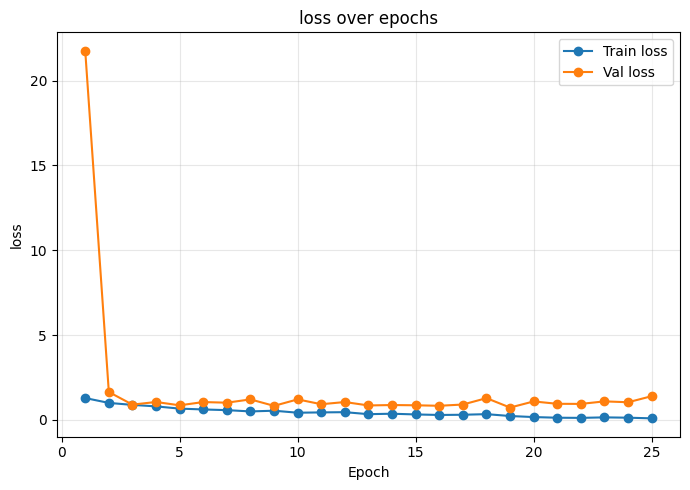

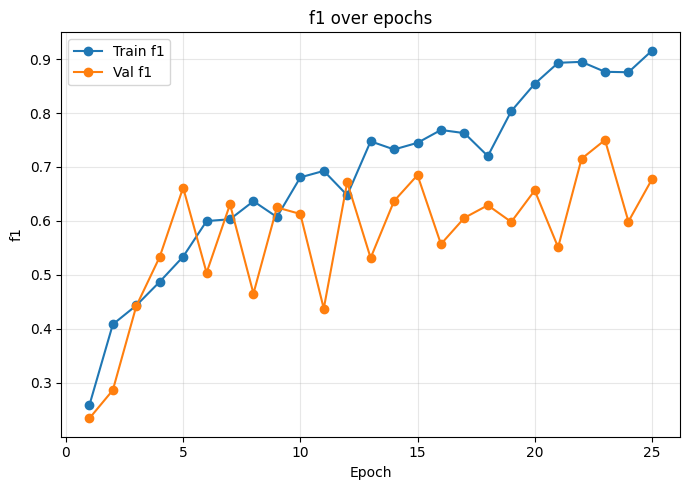

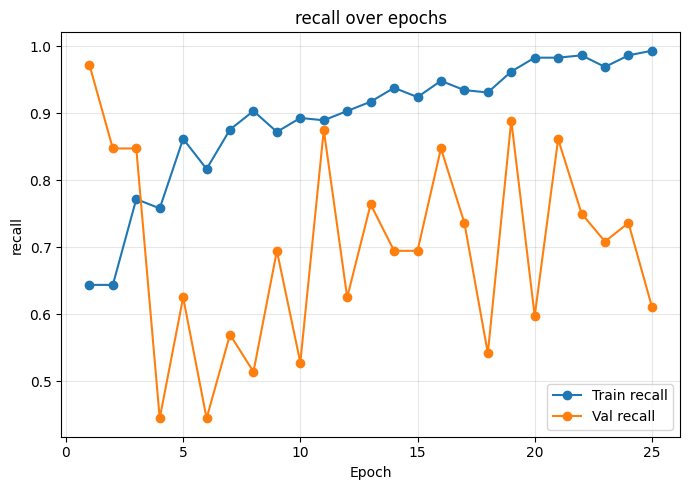

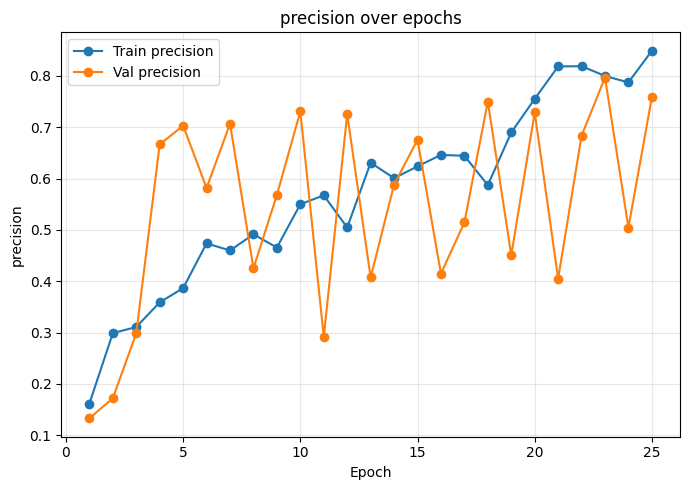

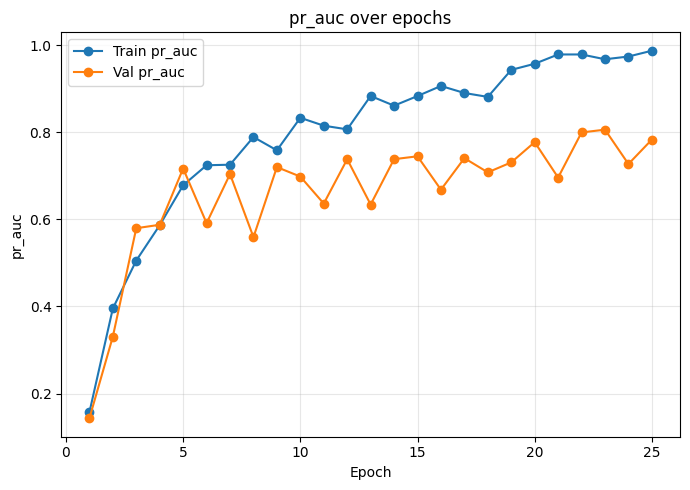

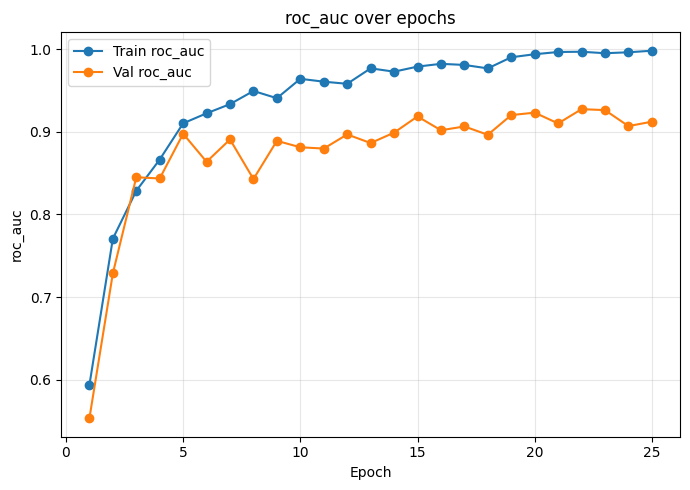

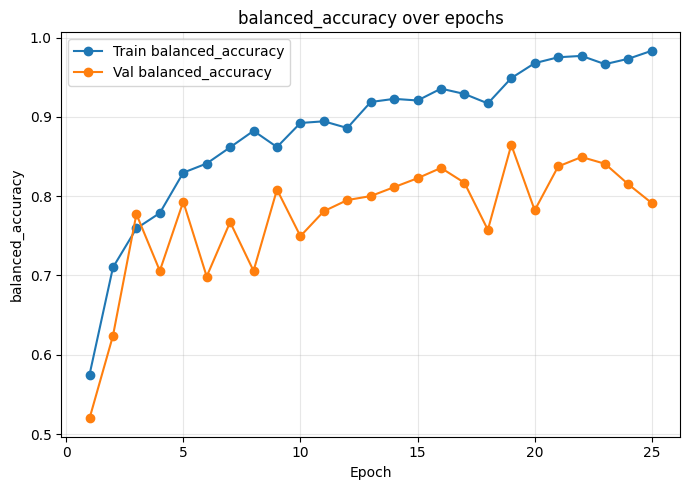

In [14]:
plot_training_history(history)

# Data Loader Pytorch

In [13]:
da = data["data"]

image_channels = [ch for ch in da.coords["channel"].values if ch != "labels"]

X_da = da.sel(channel=image_channels)
Y_da = da.sel(channel="labels")

In [ ]:
X_da

<xarray.DataArray 'data' (sample: 2803, channel: 11, x: 240, y: 240)> Size: 7GB
[1775980800 values with dtype=float32]
Coordinates:
  * sample   (sample) int16 6kB 0 1 2 3 4 5 6 ... 2797 2798 2799 2800 2801 2802
  * channel  (channel) <U6 264B '442nm' '492nm' '559nm' ... '1610nm' '2186nm'
  * x        (x) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239
  * y        (y) int16 480B 0 1 2 3 4 5 6 7 ... 232 233 234 235 236 237 238 239

In [ ]:
print(X_da.shape)
print(Y_da.shape)
print(X_da.dims)
print(Y_da.dims)

(2803, 11, 240, 240)
(2803, 240, 240)
('sample', 'channel', 'x', 'y')
('sample', 'x', 'y')


In [47]:
import numpy as np
import torch
from torch.utils.data import Dataset

import numpy as np
import torch
from torch.utils.data import Dataset


class XarraySegmentationDataset(Dataset):
    def __init__(
        self,
        da,
        label_channel="labels",
        normalize=True,
        epsilon=1e-8,
        return_sample_id=False,
        label_mapping=None,
    ):
        self.da = da
        self.label_channel = label_channel
        self.normalize = normalize
        self.epsilon = epsilon
        self.return_sample_id = return_sample_id

        self.channel_names = list(self.da.coords["channel"].values)

        if self.label_channel not in self.channel_names:
            raise ValueError(f"Label channel '{self.label_channel}' not found.")

        self.input_channels = [ch for ch in self.channel_names if ch != self.label_channel]

        raw_labels = self.da.sel(channel=self.label_channel).values
        unique_labels = np.unique(raw_labels)

        if label_mapping is None:
            self.label_mapping = {old: new for new, old in enumerate(unique_labels)}
        else:
            self.label_mapping = label_mapping

    def __len__(self):
        return self.da.sizes["sample"]

    def _normalize_per_channel(self, x: np.ndarray) -> np.ndarray:
        mean = np.nanmean(x, axis=(1, 2), keepdims=True)
        std = np.nanstd(x, axis=(1, 2), keepdims=True)

        x = (x - mean) / (std + self.epsilon)
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        return x.astype(np.float32)

    def _remap_labels(self, y: np.ndarray) -> np.ndarray:
        y_remapped = np.copy(y)
        for old, new in self.label_mapping.items():
            y_remapped[y == old] = new
        return y_remapped.astype(np.int64)

    def __getitem__(self, idx):
        sample = self.da.isel(sample=idx)

        x = sample.sel(channel=self.input_channels).values.astype(np.float32)
        y = sample.sel(channel=self.label_channel).values

        # Clean raw input first
        x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        if self.normalize:
            x = self._normalize_per_channel(x)

        y = self._remap_labels(y)

        x = torch.from_numpy(x)
        y = torch.from_numpy(y)

        if self.return_sample_id:
            sample_id = sample.coords["sample"].item()
            return x, y, sample_id

        return x, y

In [15]:
da = data["data"]

dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

x, y = dataset[0]

print("x shape:", x.shape)   # [C, H, W]
print("y shape:", y.shape)   # [H, W]
print("x dtype:", x.dtype)   # torch.float32
print("y dtype:", y.dtype)   # torch.int64

x shape: torch.Size([11, 240, 240])
y shape: torch.Size([240, 240])
x dtype: torch.float32
y dtype: torch.int64


In [16]:


label_values = np.unique(da.sel(channel="labels").values)
print(label_values)

[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


In [17]:


label_values = np.unique(da.sel(channel="labels").values)
print("Unique labels:", label_values)
num_classes = len(label_values)
print("Number of classes:", num_classes)

Unique labels: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]
Number of classes: 16


In [18]:
from torch.utils.data import random_split, DataLoader

dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
train_loader

# model shshab will be deleeted

In [ ]:
import torch
import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bottleneck(p3)

        u3 = self.up3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.conv3(u3)

        u2 = self.up2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u1 = self.up1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.conv1(u1)

        out = self.out_conv(u1)
        return out

In [ ]:
in_channels = len(dataset.input_channels)
print("Input channels:", in_channels)
print("Classes:", num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=in_channels, num_classes=num_classes).to(device)
print(model)

Input channels: 11
Classes: 16


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

#check for data sanity

In [13]:
dataset = XarraySegmentationDataset(da, label_channel="labels", normalize=True)

print("Label mapping:", dataset.label_mapping)
num_classes = len(dataset.label_mapping)
print("Num classes:", num_classes)

Label mapping: {np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}
Num classes: 16


In [14]:
batch_x, batch_y = next(iter(train_loader))

print("batch_x has NaN:", torch.isnan(batch_x).any().item())
print("batch_x has inf:", torch.isinf(batch_x).any().item())
print("batch_x min:", batch_x.min().item())
print("batch_x max:", batch_x.max().item())

print("batch_y has NaN:", torch.isnan(batch_y.float()).any().item())
print("batch_y unique:", torch.unique(batch_y))

batch_x has NaN: False
batch_x has inf: False
batch_x min: -10.194828987121582
batch_x max: 115.91560363769531
batch_y has NaN: False
batch_y unique: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


#debuging training
#checking if weights change

# Training

# New Model

In [19]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


# weighted cross entropy loss

In [23]:
from collections import Counter
import torch

def compute_class_weights(dataset, num_classes, ignore_index=None):
    counts = torch.zeros(num_classes, dtype=torch.float)

    for i in range(len(dataset)):
        x, y = dataset[i]   # assumes y is [H, W]
        y = torch.as_tensor(y)

        if ignore_index is not None:
            y = y[y != ignore_index]

        for c in range(num_classes):
            counts[c] += (y == c).sum()

    # inverse frequency
    weights = counts.sum() / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes
    return weights

In [26]:
class_weights = compute_class_weights(
    train_dataset,
    num_classes=num_classes

).to(device)

print("Class weights:", class_weights)

Class weights: tensor([3.5881e-05, 1.1449e+00, 1.4749e+00, 1.3243e+00, 3.9342e+00, 4.2757e-01,
        2.5252e-02, 1.2247e-02, 1.5234e-02, 4.2355e+00, 3.0067e-02, 4.2268e-02,
        2.9337e-01, 3.7486e-01, 2.0552e+00, 6.1021e-01], device='cuda:0')


In [41]:
import numpy as np
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader, random_split


# =========================
# 1. Reproducibility
# =========================
def set_seed(seed: int = 42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# =========================
# 2. Build dataset
# =========================
dataset = XarraySegmentationDataset(
    da=da,
    label_channel="labels",
    normalize=True,
    return_sample_id=False,
)

# Read parameters directly from dataset
in_channels = len(dataset.input_channels)
num_classes = len(dataset.label_mapping)

print("Input channels:", in_channels)
print("Num classes:", num_classes)
print("Label mapping:", dataset.label_mapping)


# =========================
# 3. Split dataset
# =========================
set_seed(42)

n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)


# =========================
# 4. Define model from dataset
# =========================
def build_model_from_dataset(
    dataset,
    encoder_name="resnet34",
    encoder_weights=None,
    device=None,
):
    in_channels = len(dataset.input_channels)
    num_classes = len(dataset.label_mapping)

    model = smp.Unet(
        encoder_name=encoder_name,
        encoder_weights=encoder_weights,
        in_channels=in_channels,
        classes=num_classes,
    )

    if device is not None:
        model = model.to(device)

    return model


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = build_model_from_dataset(
    dataset=dataset,
    encoder_name="resnet34",
    encoder_weights=None,   # use None or "imagenet" if suitable
    device=device,
)

criterion = torch.nn.CrossEntropyLoss(
    weight=class_weights

)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Input channels: 11
Num classes: 16
Label mapping: {np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}


In [42]:
import torch

def compute_metrics(preds, targets, num_classes, ignore_index=None):
    """
    preds: [B, C, H, W] (logits)
    targets: [B, H, W]
    """
    preds = torch.argmax(preds, dim=1)

    ious = []
    dices = []

    for cls in range(num_classes):
        if cls == ignore_index:
            continue

        pred_cls = (preds == cls)
        target_cls = (targets == cls)

        if ignore_index is not None:
            mask = targets != ignore_index
            pred_cls = pred_cls & mask
            target_cls = target_cls & mask

        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()

        pred_sum = pred_cls.sum().float()
        target_sum = target_cls.sum().float()

        if union == 0:
            iou = torch.tensor(1.0)  # perfect if both empty
        else:
            iou = intersection / union

        if (pred_sum + target_sum) == 0:
            dice = torch.tensor(1.0)
        else:
            dice = 2 * intersection / (pred_sum + target_sum)

        ious.append(iou)
        dices.append(dice)

    mean_iou = torch.stack(ious).mean().item()
    mean_dice = torch.stack(dices).mean().item()

    return mean_iou, mean_dice

In [43]:
# =========================
# 5. Training and validation loops
# =========================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for x, y in loader:
        x = x.to(device)                  # [B, C, H, W]
        y = y.to(device).long()           # [B, H, W]

        optimizer.zero_grad()

        logits = model(x)                 # [B, num_classes, H, W]
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, num_classes, ignore_index=None):
    model.eval()
    total_loss = 0
    total_iou = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            total_loss += loss.item()

            iou, dice = compute_metrics(
                outputs, masks,
                num_classes=num_classes,
                ignore_index=ignore_index
            )

            total_iou += iou
            total_dice += dice

    return (
        total_loss / len(loader),
        total_iou / len(loader),
        total_dice / len(loader),
    )



In [45]:
x, y = dataset[0]
print(torch.unique(torch.as_tensor(y)))
print(dataset.label_mapping)

tensor([0, 6])
{np.float32(0.0): 0, np.float32(1.0): 1, np.float32(2.0): 2, np.float32(3.0): 3, np.float32(4.0): 4, np.float32(5.0): 5, np.float32(6.0): 6, np.float32(7.0): 7, np.float32(8.0): 8, np.float32(9.0): 9, np.float32(10.0): 10, np.float32(11.0): 11, np.float32(12.0): 12, np.float32(13.0): 13, np.float32(14.0): 14, np.float32(15.0): 15}


In [44]:
# =========================
# 6. Full training loop
# =========================
num_epochs = 50
best_val_iou = 0.0
best_model_path = "best_unet_model_WeightedcrossEntropy_loss_.pth"
IGNORE_INDEX = None

history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_iou, val_dice = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=num_classes,
        ignore_index=IGNORE_INDEX,   # set this if you have unlabeled pixels
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model to {best_model_path} (best Val IoU: {best_val_iou:.4f})")

Epoch [1/50] Train Loss: 3.2331 | Val Loss: 2598.1627 | Val IoU: 0.0000 | Val Dice: 0.0001
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0000)
Epoch [2/50] Train Loss: 2.6700 | Val Loss: 19.5396 | Val IoU: 0.0057 | Val Dice: 0.0108
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0057)
Epoch [3/50] Train Loss: 2.5314 | Val Loss: 2.9722 | Val IoU: 0.0115 | Val Dice: 0.0199
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0115)
Epoch [4/50] Train Loss: 2.3740 | Val Loss: 2.6082 | Val IoU: 0.0143 | Val Dice: 0.0252
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0143)
Epoch [5/50] Train Loss: 2.2721 | Val Loss: 2.3850 | Val IoU: 0.0139 | Val Dice: 0.0242
Epoch [6/50] Train Loss: 2.1020 | Val Loss: 2.1792 | Val IoU: 0.0152 | Val Dice: 0.0261
  Saved best model to best_unet_model_WeightedcrossEntropy_loss_.pth (best Val IoU: 0.0152)
Epoch [7

KeyboardInterrupt: 

#Plot Metrics

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    # =========================
    # 1. Loss plot
    # =========================
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.legend()
    plt.grid(True)

    # =========================
    # 2. Metrics plot
    # =========================
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["val_iou"], label="Val IoU")
    plt.plot(epochs, history["val_dice"], label="Val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Segmentation Metrics")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(history)

In [ ]:
def smooth_curve(values, factor=0.8):
    smoothed = []
    for v in values:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + v * (1 - factor))
        else:
            smoothed.append(v)
    return smoothed

In [ ]:
plt.plot(epochs, smooth_curve(history["val_iou"]), label="Val IoU (smooth)")